## Sensitivity analysis
We assess how the model out varies when we vary key inputs withon likely ranges. The inputs we vary are:
* E.coli emission per person
* Flood depth
* Ingestion
* Infection parameters (alpha and beta)

### Import dependencies

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
import rasterio
from rasterio.enums import Resampling, Compression
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds
import tifffile as tf
import yaml
import utm
from osgeo import gdal
from SALib.sample import sobol as sobol_sampler
from SALib.analyze import sobol
import dask.array as da
import pickle
import seaborn as sns


### Define pathogen

In [2]:
pathogen = 'E.coli' # select the pathogen for the simulation. Option at the moment is only 'E.coli'

### Set directories

In [3]:
base_dir = r'P:\11210268-014-flood-and-health\FloodsAndHealthTool-main'
scen_dir = os.path.join(base_dir, 'tool', 'default_ymls')
maps_dirpre = os.path.join(base_dir, 'output', 'preprocessing')
emissions_inputs = os.path.join(base_dir, 'examples', 'Emissions')
output_dir = os.path.join(base_dir, 'output','sensitivity_analysis')

flood_path = os.path.join(maps_dirpre, 'flooded_zoom_new.tif')
demographic_path = os.path.join(maps_dirpre, 'clipped_population.tif')
emissions_path = os.path.join(maps_dirpre, 'ecoli_emissions_cropped.tif')

### Define function to generate emissions rasters

In [4]:
def makeEmissionsRaster(i, ecoli_level):
    output_raster = os.path.join(output_dir, 'emissionsRasters',"ecoli_emissions" + str(i) + ".tif")

    # ✅ Run Processing in Parallel with Dask (Ensure dtype is specified)
    emissions = da.map_blocks(
        compute_emissions, 
        population, urban_mask, rural_mask, ecoli_level,
        dtype=np.float64
    )

    # 🚀 Force Execution & Compute Results
    emissions = emissions.compute()

    # Define metadata for the emissions raster
    emissions_meta = profile.copy()
    emissions_meta.update({
        'count': 1,  # Single band
        'dtype': 'float64',
    })

    # Use in-memory raster and WarpedVRT to crop emissions
    with rasterio.MemoryFile() as memfile:
        with memfile.open(**emissions_meta) as emissions_raster:
            emissions_raster.write(emissions, 1)

            # Use WarpedVRT for alignment to flood raster
            with WarpedVRT(
                emissions_raster,
                crs=flood_crs,
                transform=flood_transform,
                height=flood_shape[0],
                width=flood_shape[1],
                resampling=Resampling.nearest,
            ) as vrt:
                emissions_window = from_bounds(*flood_bounds, vrt.transform)
                emissions_cropped = vrt.read(1, window=emissions_window)

    # At this point, emissions_cropped is the cropped numpy array
    # If needed, update metadata to reflect the new shape, transform, etc.
    cropped_meta = emissions_meta.copy()
    cropped_meta.update({
        'height': flood_shape[0],
        'width': flood_shape[1],
        'transform': flood_transform,
        'crs': flood_crs,
    })

    # If you want to save the cropped raster:
    with rasterio.open(output_raster, 'w', **cropped_meta) as dst:
        dst.write(emissions_cropped, 1)


### Define supplementary functions

In [5]:
def load_tiff(file_path, dtype=np.float32):
    """Loads a TIFF file and handles NoData values."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with tf.TiffFile(file_path) as tif:
        data = tif.asarray().astype(dtype)
        no_data_value = tif.pages[0].tags.get('GDAL_NODATA', None)

        if no_data_value:
            try:
                no_data_value = float(no_data_value.value)
                data[data == no_data_value] = np.nan  # Set NoData to NaN
            except ValueError:
                pass  # Ignore if conversion fails

    return data

def load_multiband_tiff(file_path):
    """Loads a multi-band TIFF file (e.g., population density)."""
    dataset = gdal.Open(file_path)
    if dataset is None:
        raise RuntimeError(f"Failed to open dataset: {file_path}")

    bands = dataset.RasterCount  # Get number of bands
    return np.array([dataset.GetRasterBand(i + 1).ReadAsArray().astype(np.float32) for i in range(bands)])

def get_utm_zone(source_path):
    """Get most appropriate UTM zone for area in question"""
    with rasterio.open(source_path) as src:
        bounds = src.bounds
    
    # Calculate the center latitude and longitude of the raster
    center_lon = (bounds.left + bounds.right) / 2
    center_lat = (bounds.top + bounds.bottom) / 2
    
    # Get UTM zone information from lat/lon
    utm_zone = utm.from_latlon(center_lat, center_lon)
    
    # Extract zone number and hemisphere
    zone_number = utm_zone[2]
    hemisphere = utm_zone[3]
    
    # If the latitude is negative, it's in the southern hemisphere
    if center_lat < 0:
        hemisphere = 'S'
    
    # Determine the EPSG code based on hemisphere and zone number
    if hemisphere == 'S':
        epsg_code = 32700 + zone_number  # Southern Hemisphere
    else:
        epsg_code = 32600 + zone_number  # Northern Hemisphere

    return epsg_code### Define supplementary functions

def get_cell_area(source_path):
    """"Get area of gridcell in m2."""
    with rasterio.open(source_path) as src:
        # Transform the raster to a CRS with units in meters
        dst_crs = get_utm_zone(source_path)
        transform, width, height = rasterio.warp.calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)

        # Create an empty array to store reprojected data (not saving to disk)
        reprojected_data = np.empty((height, width), dtype=src.dtypes[0])
        
        # Reproject the raster data into the new CRS
        reproject(
            source=rasterio.band(src, 1),
            destination=reprojected_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
        )
        
        # Cell dimensions in meters
        cell_width = transform[0]  # X resolution
        cell_height = -transform[4]  # Y resolution (negative because Y decreases in raster)
        
        # Area of a single cell
        cell_area = cell_width * cell_height
        return cell_area

# 🏎 Parallel Processing: Compute E. coli Emissions
def compute_emissions(pop_chunk, urban_chunk, rural_chunk, ecoli_level):
    """Processes a chunk of the raster in parallel using Dask."""
    sanitation_factor = da.ones_like(pop_chunk, dtype=np.float64)  # Default = 1
    # Ensure urban and rural masks are boolean
    urban_chunk = urban_chunk.astype(bool)
    rural_chunk = rural_chunk.astype(bool)
    # Apply sanitation factors
    sanitation_factor = da.where(urban_chunk, urban_sanitation_factor, sanitation_factor)
    sanitation_factor = da.where(rural_chunk, rural_sanitation_factor, sanitation_factor)
    return pop_chunk * ecoli_level * sanitation_factor * weight_factor

### Model setup

In [6]:
# get area of gridcell in m2
cell_area = get_cell_area(flood_path)

# Load single-band flood data
flood = load_tiff(flood_path)
# If there are positive values, make these negative
flood[flood>0] = -flood[flood>0]

# Load multi-band population data (Children, Adults, Population Density)
children, adults, popdens = load_multiband_tiff(demographic_path)

# Read exposure data from YAML file
with open(os.path.join(scen_dir,"Ingestion_scenarios.yml"), "r") as file:
    exposure_data = yaml.safe_load(file)


c:\SnapVolumesTemp\MountPoints\{45c63495-0000-0000-0000-100000000000}\{42c8c930-553d-45d4-a2b5-e88c61fac556}\SVROOT\Users\dellar\AppData\Local\anaconda3\envs\floodshealth\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


### Define model function

In [47]:
def run_model(i, params):
    """Runs the model, based on prescribed inputs"""
    emissionsRaster = os.path.join(output_dir, 'emissionsRasters',"ecoli_emissions" + str(i) + ".tif")
    emissions = load_tiff(emissionsRaster)

    # Calculate E.coli concentration/100ml
    EcoliConc = emissions/(cell_area * (-1) * flood * params[1] *10000)

    # Adjust flood data and create classes for the flooded area ###
    wclass = flood * params[1]                               # create a copy of the flood map
    wclass[wclass>0]=np.nan                                  # filter the dry land out        
    wclass[np.logical_and(wclass<0,wclass>=-0.1)]= 1         # assign the classes
    wclass[np.logical_and(wclass<-0.1,wclass>=-0.5)]=2                                  
    wclass[np.logical_and(wclass<-0.5,wclass>=-1.5)]=3
    wclass[wclass<-1.5]= 4
    
    # Process exposure data
    exposure_data2 = {}
    event_in_hours = 1 #e.g. 1 if event lasts 1 hour; 0.25 if event lasts 15 mins
    for scenario, details in exposure_data.items():
        quantity, unit = details["ing"], details["unit"]
        quantity = quantity * params[2]
        if unit == "ml/event":
            unit = "ml/h"
            quantity = quantity / event_in_hours
        exposure_data2[scenario] = {"ing": quantity, "unit": unit}

    #Calculate adult dose
    dose_ad = wclass.copy()
    dose_ad[dose_ad==1]=np.nan
    dose_ad[np.logical_or(dose_ad==2,dose_ad==3)] = exposure_data2["Wading_Adult"]["ing"]*EcoliConc[np.logical_or(dose_ad==2,dose_ad==3)]/100 #Divide by 100 because E.Coli is per 100ml
    dose_ad[dose_ad==4] = exposure_data2["Swimming_Adult"]["ing"]*EcoliConc[dose_ad==4]/100
    
    # Calculate child dose
    dose_ch = wclass.copy()
    dose_ch[dose_ch==1]=np.nan
    dose_ch[dose_ch==2] = exposure_data2["Wading_Children"]["ing"]*EcoliConc[dose_ch==2]/100
    dose_ch[np.logical_or(dose_ch==3,dose_ch==4)] = exposure_data2["Swimming_Children"]["ing"]*EcoliConc[np.logical_or(dose_ch==3,dose_ch==4)]/100

    # Retrieve pathogen-specific parameters
    alpha = params[3]
    beta = params[4]
    
    # Calculate infection risk
    InfRisk_Ad = 1 - (1+(dose_ad/beta))**-alpha
    InfRisk_Ch = 1 - (1+(dose_ch/beta))**-alpha

    # Calculate number of infections
    Inf_ad = InfRisk_Ad * adults
    Inf_ch = InfRisk_Ch * children
    totAd = int(round(np.nansum(Inf_ad),0))
    totCh = int(round(np.nansum(Inf_ch),0))

    return totAd, totCh

### Define input ranges to vary

In [25]:
# E.Coli emissions
# This was originally set to 1e9 CFU/100mL E. coli Emission Per Person
Ecoli_low = 1e7
Ecoli_high = 1e10

# Flood level
# Multiply all values in raster by this amount
Flood_low = 0.5
Flood_high = 1.5

# Ingestion
# Multiply all ingestion values by this amount
Ingestion_low = 0.5
Ingestion_high = 1.5

# Infection parameters
alpha_low = 0.05
alpha_high = 0.4
beta_low = 2
beta_high = 150

### Sensitivity analysis setup

In [26]:
# Define the sensitivity problem
problem = {
    'num_vars': 5,
    'names': ['Ecoli','flood','ingestion','alpha','beta'],
    'bounds': [[Ecoli_low, Ecoli_high],[Flood_low, Flood_high],[Ingestion_low, Ingestion_high], [alpha_low, alpha_high],[beta_low, beta_high]]
}

# Generate samples
param_values = sobol_sampler.sample(problem, 128)

# save param_values
with open(os.path.join(output_dir, 'param_values.pkl'), 'wb') as f:
    pickle.dump(param_values, f)

# load param_values
with open(os.path.join(output_dir, 'param_values.pkl'), 'rb') as f:
    param_values = pickle.load(f)

### Create new emissions rasters

In [28]:
# Create new emissions rasters
population_raster = os.path.join(maps_dirpre, "moz_population_combined_compressed.tif")
urban_rural_raster = os.path.join(emissions_inputs, "Urban_rural_classification.tif")
sanitation_file = os.path.join(emissions_inputs, "sanitation_data.yaml")
gdp_file = os.path.join(emissions_inputs, "gdp_data.yaml")

#GDP data
with open(gdp_file, "r") as file:
    gdp_data = yaml.safe_load(file)

country_name = "Mozambique"

gdp_per_capita = gdp_data["countries"].get(country_name, {}).get("GDP_per_capita", None)
weight_factor = max(0.5, (1 - (gdp_per_capita / 80)))

# Sanitation data
with open(sanitation_file, "r") as file:
    sanitation_data = yaml.safe_load(file)

country_coverage = sanitation_data["countries"][country_name]["sanitation_coverage"]

# Extract global reduction factors (same for all countries)
sanitation_types = ["Safe", "Advanced", "Basic", "None"]
urban_reduction_factors = np.array([
    sanitation_data["sanitation_types"][st]["urban_reduction_factor"] for st in sanitation_types
])
rural_reduction_factors = np.array([
    sanitation_data["sanitation_types"][st]["rural_reduction_factor"] for st in sanitation_types
])

# Convert sanitation coverage to NumPy arrays
urban_coverage = np.array([country_coverage[st]["urban"] / 100 for st in sanitation_types])
rural_coverage = np.array([country_coverage[st]["rural"] / 100 for st in sanitation_types])

# Compute weighted sanitation factors
urban_sanitation_factor = np.dot(urban_reduction_factors, urban_coverage)
rural_sanitation_factor = np.dot(rural_reduction_factors, rural_coverage)

# 📌 Load Population Raster & Get Extent
with rasterio.open(population_raster) as pop_src:
    pop_transform = pop_src.transform
    pop_bounds = pop_src.bounds  # Get extent of population raster
    pop_crs = pop_src.crs  # Coordinate Reference System
    pop_res = pop_src.res  # Resolution (pixel size)
    pop_shape = (pop_src.height, pop_src.width)  # Shape of raster
    profile = pop_src.profile  # Save raster metadata

# 📌 Load & Clip Urban-Rural Raster to Match Population Raster
with rasterio.open(urban_rural_raster) as urb_src:
    # Ensure CRS Matches
    if urb_src.crs != pop_crs:
        raise ValueError("⚠️ CRS mismatch! Urban-rural raster must match population raster.")

    # Use WarpedVRT to Align Urban-Rural Raster to Population Raster
    with WarpedVRT(urb_src, crs=pop_crs, transform=pop_transform, height=pop_shape[0], width=pop_shape[1], resampling=rasterio.enums.Resampling.nearest) as vrt:
        urb_window = from_bounds(*pop_bounds, vrt.transform)
        urban_rural = vrt.read(1, window=urb_window).astype(np.int8)  # Read only clipped area

# ✅ Convert Urban/Rural Classification into Boolean Masks
urban_mask = da.from_array(urban_rural == 1, chunks=(250, 250))
rural_mask = da.from_array(urban_rural == 2, chunks=(250, 250))

# 📌 Load Population Raster (Ensure Single Band & Correct Shape)
with rasterio.open(population_raster) as pop_src:
    population = da.from_array(pop_src.read(3).squeeze(), chunks=(250, 250)).astype(np.float64)  # Ensure (height, width)

# ✅ Ensure All Arrays Have the Same Shape & Chunking
chunk_size = population.chunks  # Ensure chunking matches population raster
urban_mask = urban_mask.rechunk(chunk_size)
rural_mask = rural_mask.rechunk(chunk_size)

# Load flood raster and get its properties
with rasterio.open(flood_path) as flood_src:
    flood_transform = flood_src.transform
    flood_bounds = flood_src.bounds  # Extent of flood raster
    flood_crs = flood_src.crs  # CRS of flood raster
    flood_res = flood_src.res  # Resolution
    flood_shape = (flood_src.height, flood_src.width)  # Shape of flood raster
    flood_profile = flood_src.profile  # Metadata

# Create new rasters
startnum = 0
for i, ecoli_level in enumerate([x[0] for x in param_values[startnum:]]):
    z = i+startnum
    print(z)
    makeEmissionsRaster(z, ecoli_level)

0


C:\Users\dellar\AppData\Local\Temp\ipykernel_5532\2642653803.py:86: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  makeEmissionsRaster(z, ecoli_level)


1


C:\Users\dellar\AppData\Local\Temp\ipykernel_5532\2642653803.py:86: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  makeEmissionsRaster(z, ecoli_level)


2


...

C:\Users\dellar\AppData\Local\Temp\ipykernel_5532\2642653803.py:86: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  makeEmissionsRaster(z, ecoli_level)


1534


C:\Users\dellar\AppData\Local\Temp\ipykernel_5532\2642653803.py:86: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  makeEmissionsRaster(z, ecoli_level)


1535


C:\Users\dellar\AppData\Local\Temp\ipykernel_5532\2642653803.py:86: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  makeEmissionsRaster(z, ecoli_level)


### Run model

In [48]:
# Run the model for each sample and collect outputs
outputs = []
for i, params in enumerate(param_values):
    output = run_model(i, params)
    outputs.append(output)

### Check concentrations
Ensure max E.coli concentration does not exceed reported ranges

In [ ]:
def checkConc(i,params):
    emissionsRaster = os.path.join(output_dir, 'emissionsRasters',"ecoli_emissions" + str(i) + ".tif")
    emissions = load_tiff(emissionsRaster)
    EcoliConc = emissions/(cell_area * (-1) * flood * params[1] *10000)
    return np.nanmax(EcoliConc)

concs = []
for i, params in enumerate(param_values):
    conc = checkConc(i,params)
    concs.append(conc)

max(concs)
#76227791.6 - within range in P:\\11210268-014-flood-and-health\FloodsAndHealthTool-main\examples\Data bronnen\Pathogen_conc._floodwater.xlsx

### Analyse results

In [49]:
outputs = np.array(outputs)  # Shape should be (1536, 2)
output_ad = outputs[:, 0]  # First output
output_ch = outputs[:, 1]  # Second output

# Perform Sobol analysis for each output
sobol_results_ad = sobol.analyze(problem, output_ad)
sobol_results_ch = sobol.analyze(problem, output_ch)

c:\SnapVolumesTemp\MountPoints\{45c63495-0000-0000-0000-100000000000}\{42c8c930-553d-45d4-a2b5-e88c61fac556}\SVROOT\Users\dellar\AppData\Local\anaconda3\envs\floodshealth\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


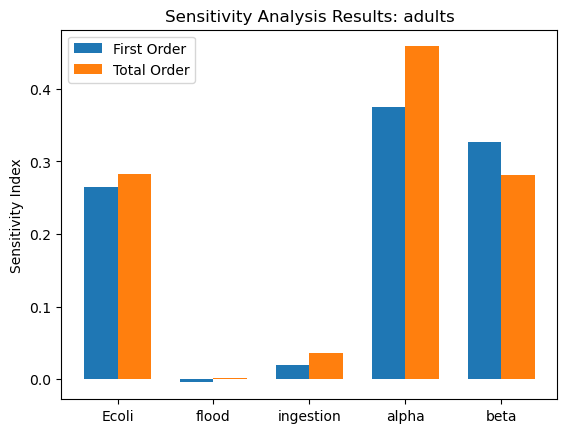

In [50]:
#Plot first order and total order sensitivity indices.
#These tell you the proportion of the output variance that is explained by each parameter.
#Total order includes interactions, first order is just the individual effects
labels = problem['names']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, sobol_results_ad['S1'], width, label='First Order')
ax.bar(x + width/2, sobol_results_ad['ST'], width, label='Total Order')

ax.set_ylabel('Sensitivity Index')
ax.set_title('Sensitivity Analysis Results: adults')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

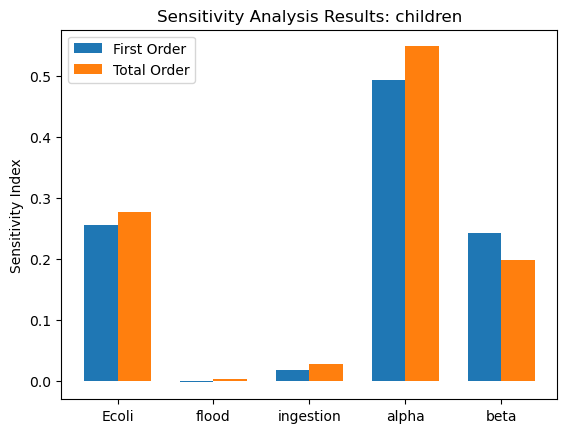

In [51]:
fig, ax = plt.subplots()
ax.bar(x - width/2, sobol_results_ch['S1'], width, label='First Order')
ax.bar(x + width/2, sobol_results_ch['ST'], width, label='Total Order')

ax.set_ylabel('Sensitivity Index')
ax.set_title('Sensitivity Analysis Results: children')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

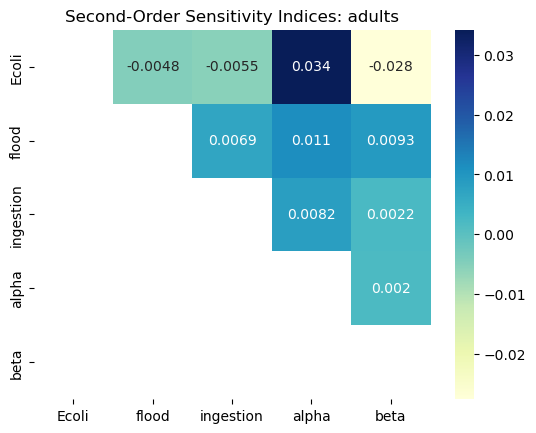

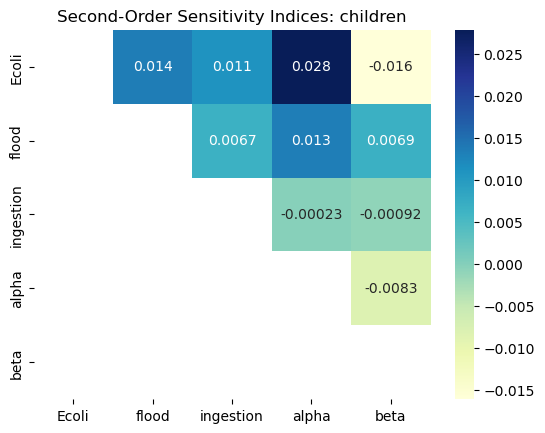

In [52]:
#Plot interaction effects (proportion of the output variance that is explained by each interaction)

#adults
sns.heatmap(np.array(sobol_results_ad['S2']), annot=True, cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.title("Second-Order Sensitivity Indices: adults")
plt.show()

#children
sns.heatmap(np.array(sobol_results_ch['S2']), annot=True, cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.title("Second-Order Sensitivity Indices: children")
plt.show()

71945
195
22274
152


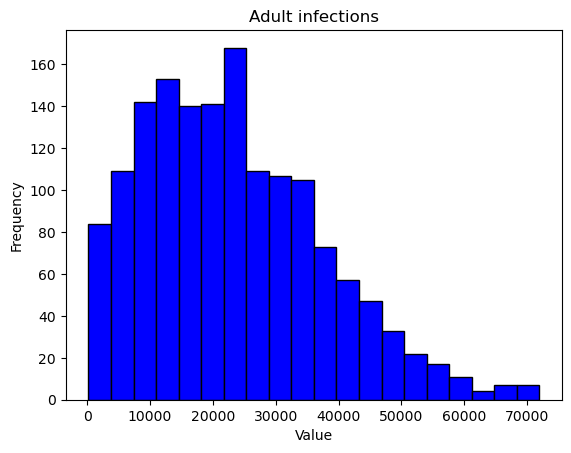

In [53]:
print(max(output_ad))
print(min(output_ad))
print(max(output_ch))
print(min(output_ch))

plt.hist(output_ad, bins=20, color='blue', edgecolor='black')

# Adding labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Adult infections')

# Display the plot
plt.show()

In [54]:
largest_indices = np.argsort(output_ad)[-20:][::-1]
print(param_values[largest_indices])

#Largest outputs have high ecoli, high alpha and low beta

[[7.14760492e+09 1.09843714e+00 1.45330252e+00 3.96304658e-01
  4.87474233e+00]
 [9.19458940e+09 1.28132446e+00 1.03173881e+00 3.87254134e-01
  4.81713705e+00]
 [7.14760492e+09 1.09843714e+00 1.19958694e+00 3.96304658e-01
  4.87474233e+00]
 [7.14760492e+09 1.04352696e+00 1.19958694e+00 3.96304658e-01
  4.87474233e+00]
 [8.08923684e+09 1.13282657e+00 1.15089068e+00 3.64719309e-01
  4.03814347e+00]
 [6.08018464e+09 1.09843714e+00 1.19958694e+00 3.96304658e-01
  4.87474233e+00]
 [8.08923684e+09 7.73105484e-01 1.15089068e+00 3.64719309e-01
  4.03814347e+00]
 [9.14065141e+09 7.61291904e-01 1.25887024e+00 3.63608660e-01
  6.44134642e+00]
 [7.27565143e+09 8.67245574e-01 1.28786020e+00 3.76154269e-01
  7.19971219e+00]
 [8.08923684e+09 7.73105484e-01 7.58289650e-01 3.64719309e-01
  4.03814347e+00]
 [9.19458940e+09 5.75597660e-01 1.14530419e+00 3.87254134e-01
  4.81713705e+00]
 [6.08018464e+09 1.04352696e+00 1.45330252e+00 3.37016354e-01
  4.87474233e+00]
 [7.14760492e+09 1.09843714e+00 1.199586